<a href="https://colab.research.google.com/github/Friskkun/Project-coding-storage/blob/main/Freezing_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

eps at end: [0.0, 0.0, 0.0] eps_end: [0.0, 0.0, 0.0]


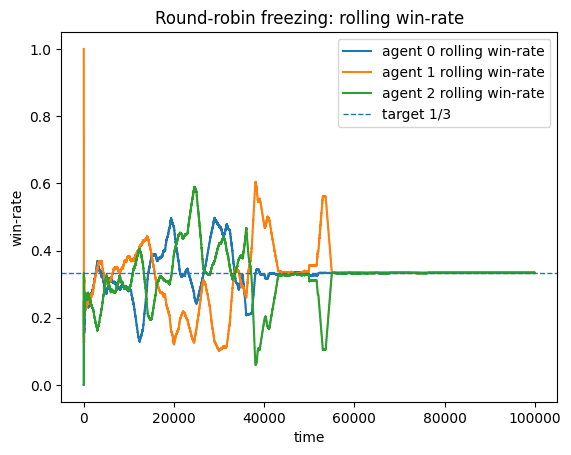

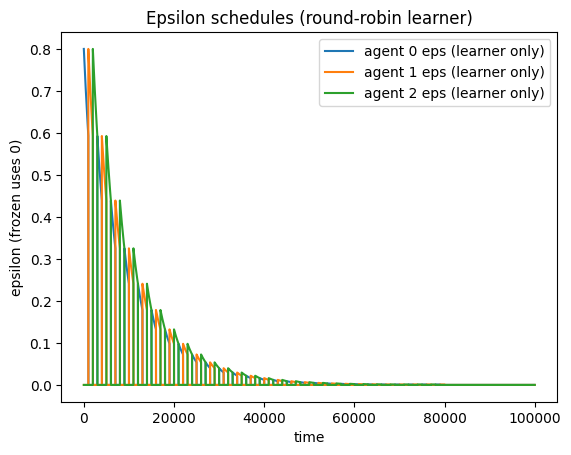

Final avg win-rate (last 5000 steps): [0.3332 0.3334 0.3334]
Total avg win-rate: [0.33267 0.32655 0.32397]


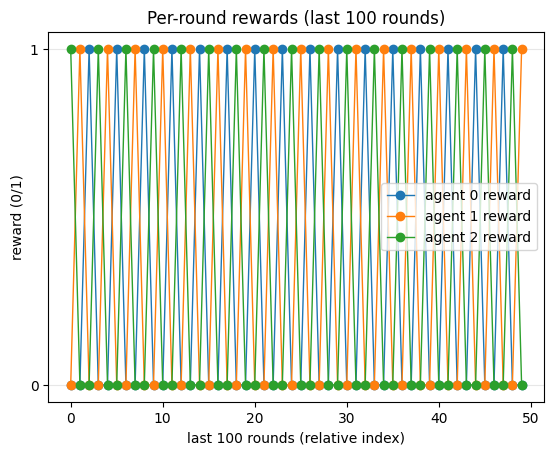

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ----------------------------
# Minority Game Environment (N=3)
# ----------------------------
class MinorityGame:
    """
    N=3, actions in {0,1}.
    Minority side (strictly fewer agents) gets reward 1, others 0.
    Public history signal: minority_action (0/1) if exists else 0.
    History length = m bits -> integer state in [0, 2^m - 1].
    """
    def __init__(self, m=3, seed=0):
        self.n_agents = 3
        self.m = m
        self.base_states = 2 ** m
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.t = 0
        self.hist = deque([0] * self.m, maxlen=self.m)
        return self._hist_to_int()

    def _hist_to_int(self):
        s = 0
        for b in self.hist:
            s = (s << 1) | int(b)
        return s

    def step(self, actions):
        actions = np.asarray(actions, dtype=int)
        ssum = int(actions.sum())

        rewards = np.zeros(3, dtype=float)
        minority_action = None

        if ssum == 1:
            minority_action = 1
        elif ssum == 2:
            minority_action = 0

        if minority_action is not None:
            winners = (actions == minority_action)
            rewards[winners] = 1.0

        signal = 0 if minority_action is None else int(minority_action)
        self.hist.append(signal)

        self.t += 1
        next_state = self._hist_to_int()
        return next_state, rewards, minority_action


# ----------------------------
# Q-learning Agent (no punishment)
# ----------------------------
class QAgent:
    def __init__(self, n_states, n_actions=2, alpha=0.1, gamma=0.95,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.999, seed=0):
        self.Q = np.zeros((n_states, n_actions), dtype=float)
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.eps = float(eps_start)
        self.eps_start = float(eps_start)
        self.eps_end = float(eps_end)
        self.eps_decay = float(eps_decay)
        self.n_actions = int(n_actions)
        self.rng = np.random.default_rng(seed)


    def act(self, s, eps_override=None):
      eps = self.eps if eps_override is None else float(eps_override)
      if self.rng.random() < eps:
        return int(self.rng.integers(self.n_actions))

      q = self.Q[s]
    # random tie-break among max actions
      max_q = np.max(q)
      max_actions = np.flatnonzero(np.isclose(q, max_q))
      return int(self.rng.choice(max_actions))


    def update(self, s, a, r, s_next):
        td_target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s, a] += self.alpha * (td_target - self.Q[s, a])

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)

    def reset_eps(self):
        self.eps = self.eps_start


# ----------------------------
# State augmentation: add phase (t mod 3)
# ----------------------------
def aug_state(history_state, t, base_states):
    return int(history_state + (t % 3) * base_states)


# ----------------------------
# Training with round-robin freezing
# ----------------------------
def run_round_robin(
    m=3,
    steps=30000,
    seed=0,
    alpha=0.1,
    gamma=0.95,
    eps_start=0.8,
    eps_end=0.02,
    eps_decay=0.9995,
    epoch_len=2000,         # 每个 learner 连续学习多少步再换下一个
    frozen_eps=0.0,         # 冻结者纯贪心
    log_window=1000,
    eps_off = 0.8
):
    env = MinorityGame(m=m, seed=seed)
    base_states = env.base_states
    n_states = base_states * 3

    agents = [
        QAgent(n_states, alpha=alpha, gamma=gamma,
               eps_start=eps_start, eps_end=eps_end, eps_decay=eps_decay,
               seed=seed + 10 + i)
        for i in range(3)
    ]

    history_state = env.reset()

    rewards_hist = np.zeros((steps, 3), dtype=float)
    eps_hist = np.zeros((steps, 3), dtype=float)
    learner_hist = np.zeros(steps, dtype=int)
    eps_off_time = int(eps_off * steps)
    for t in range(steps):
        if t >= eps_off_time:
          for ag in agents:
            ag.eps = 0.0
            ag.eps_end = 0.0
        # 当前 epoch 的 learner
        learner = (t // epoch_len) % 3
        learner_hist[t] = learner

        s = aug_state(history_state, t, base_states)

        actions = []
        for i, ag in enumerate(agents):
            if i == learner:
                actions.append(ag.act(s))                 # learner 用自己的 eps
            else:
                actions.append(ag.act(s, frozen_eps))     # frozen 用 eps=0

        next_history_state, rewards, _ = env.step(actions)

        s_next = aug_state(next_history_state, t + 1, base_states)

        # 只更新 learner
        agL = agents[learner]
        agL.update(s, actions[learner], rewards[learner], s_next)
        if t<eps_off_time:
          agL.decay_eps()

        # frozen 的 eps 不动（保持稳定）
        for i, ag in enumerate(agents):
            eps_hist[t, i] = ag.eps if i == learner else frozen_eps

        rewards_hist[t] = rewards
        history_state = next_history_state
    print("eps at end:", [ag.eps for ag in agents], "eps_end:", [ag.eps_end for ag in agents])

    # rolling win-rate
    win_rate = np.zeros((steps, 3), dtype=float)
    for i in range(3):
        csum = np.cumsum(rewards_hist[:, i])
        for t in range(steps):
            lo = max(0, t - log_window + 1)
            total = csum[t] - (csum[lo - 1] if lo > 0 else 0.0)
            win_rate[t, i] = total / (t - lo + 1)

    return rewards_hist, eps_hist, win_rate, learner_hist


if __name__ == "__main__":
    rewards_hist, eps_hist, win_rate, learner_hist = run_round_robin(
        m=3,
        steps=100000,
        seed=42,
        alpha=0.12,
        gamma=0.95,
        eps_start=0.8,
        eps_end=0.001,
        eps_decay=0.9997,
        epoch_len=1000,   # 你可以试 1000/3000/10000
        frozen_eps=0.00,
        log_window=2000,
        eps_off = 0.8
    )

    t = np.arange(rewards_hist.shape[0])

    plt.figure()
    plt.plot(t, win_rate[:, 0], label="agent 0 rolling win-rate")
    plt.plot(t, win_rate[:, 1], label="agent 1 rolling win-rate")
    plt.plot(t, win_rate[:, 2], label="agent 2 rolling win-rate")
    plt.axhline(1/3, linestyle="--", linewidth=1, label="target 1/3")
    plt.xlabel("time")
    plt.ylabel("win-rate")
    plt.legend()
    plt.title("Round-robin freezing: rolling win-rate")
    plt.show()

    plt.figure()
    plt.plot(t, eps_hist[:, 0], label="agent 0 eps (learner only)")
    plt.plot(t, eps_hist[:, 1], label="agent 1 eps (learner only)")
    plt.plot(t, eps_hist[:, 2], label="agent 2 eps (learner only)")
    plt.xlabel("time")
    plt.ylabel("epsilon (frozen uses 0)")
    plt.legend()
    plt.title("Epsilon schedules (round-robin learner)")
    plt.show()

    print("Final avg win-rate (last 5000 steps):", rewards_hist[-5000:].mean(axis=0))
    print("Total avg win-rate:", rewards_hist.mean(axis=0))

    # ---- plot last 100 rounds per-agent rewards ----
last = 50
R = rewards_hist[-last:]                 # shape (100, 3)
x = np.arange(last)

plt.figure()
plt.plot(x, R[:, 0], marker='o', linewidth=1, label='agent 0 reward')
plt.plot(x, R[:, 1], marker='o', linewidth=1, label='agent 1 reward')
plt.plot(x, R[:, 2], marker='o', linewidth=1, label='agent 2 reward')
plt.yticks([0, 1])
plt.xlabel('last 100 rounds (relative index)')
plt.ylabel('reward (0/1)')
plt.title('Per-round rewards (last 100 rounds)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

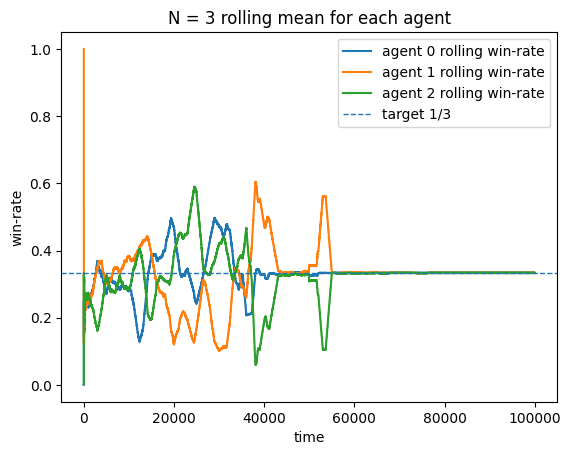

In [ ]:
plt.figure()
plt.plot(t, win_rate[:, 0], label="agent 0 rolling win-rate")
plt.plot(t, win_rate[:, 1], label="agent 1 rolling win-rate")
plt.plot(t, win_rate[:, 2], label="agent 2 rolling win-rate")
plt.axhline(1/3, linestyle="--", linewidth=1, label="target 1/3")
plt.xlabel("time")
plt.ylabel("win-rate")
plt.legend()
plt.title("N = 3 rolling mean for each agent")
plt.show()

eps at end: [0.0, 0.0, 0.0] eps_end: [0.0, 0.0, 0.0]


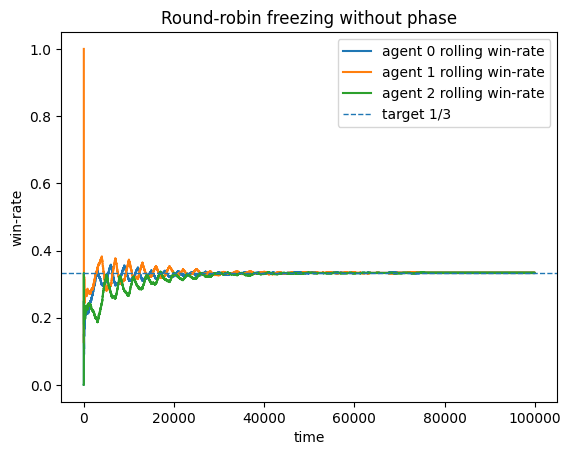

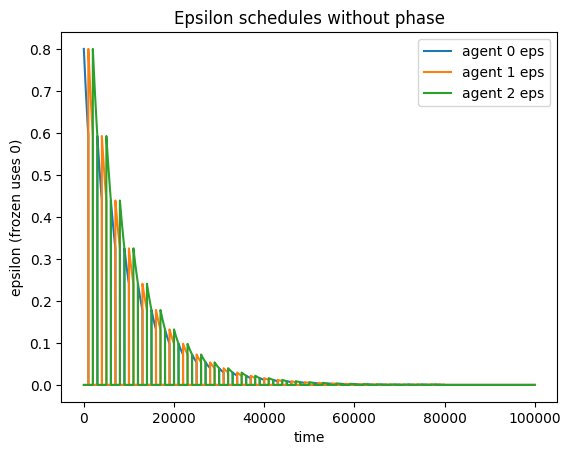

Final avg win-rate (last 5000 steps): [0.3334 0.3334 0.3332]
Total avg win-rate: [0.33001 0.33242 0.32313]


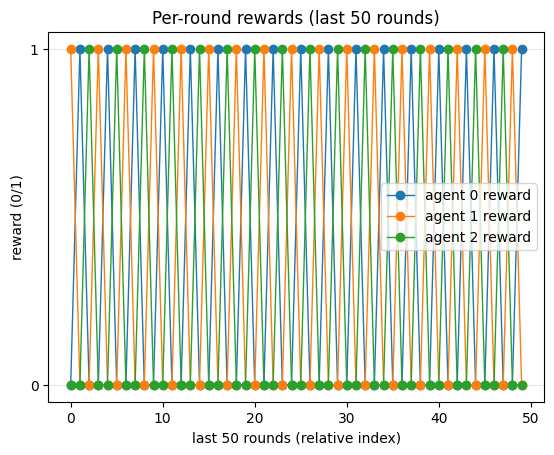


Agent 0 Q-table:
state= 0, Q=[6.32872584 7.01138778]
state= 1, Q=[6.01125677 6.32778265]
state= 2, Q=[6.01134564 6.66082384]
state= 3, Q=[5.90161166 6.32774464]
state= 4, Q=[6.66078481 7.01139351]
state= 5, Q=[5.66214063 6.32777589]
state= 6, Q=[5.84501695 6.66081727]
state= 7, Q=[5.46582007 6.63178289]

Agent 1 Q-table:
state= 0, Q=[6.32777885 5.6749811 ]
state= 1, Q=[6.32773833 6.66082384]
state= 2, Q=[7.01139351 6.01139125]
state= 3, Q=[6.31680197 6.66081311]
state= 4, Q=[6.32778265 6.01136768]
state= 5, Q=[3.76012655 1.83285985]
state= 6, Q=[7.01139206 5.82349655]
state= 7, Q=[7.09447562 4.49735029]

Agent 2 Q-table:
state= 0, Q=[6.66082204 6.21305177]
state= 1, Q=[7.01139351 6.01139246]
state= 2, Q=[5.71081554 6.32778265]
state= 3, Q=[6.65903475 2.63381015]
state= 4, Q=[6.66082384 6.32776863]
state= 5, Q=[5.99238817 6.01139233]
state= 6, Q=[4.58276211 6.18554453]
state= 7, Q=[0. 0.]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ----------------------------
# Minority Game Environment (N=3)
# ----------------------------
class MinorityGame:
    """
    N=3, actions in {0,1}.
    Minority side (strictly fewer agents) gets reward 1, others 0.
    Public history signal: minority_action (0/1) if exists else 0.
    History length = m bits -> integer state in [0, 2^m - 1].
    """
    def __init__(self, m=3, seed=0):
        self.n_agents = 3
        self.m = m
        self.base_states = 2 ** m
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.t = 0
        self.hist = deque([0] * self.m, maxlen=self.m)
        return self._hist_to_int()

    def _hist_to_int(self):
        s = 0
        for b in self.hist:
            s = (s << 1) | int(b)
        return s

    def step(self, actions):
        actions = np.asarray(actions, dtype=int)
        ssum = int(actions.sum())

        rewards = np.zeros(3, dtype=float)
        minority_action = None

        if ssum == 1:
            minority_action = 1
        elif ssum == 2:
            minority_action = 0

        if minority_action is not None:
            winners = (actions == minority_action)
            rewards[winners] = 1.0

        signal = 0 if minority_action is None else int(minority_action)
        self.hist.append(signal)

        self.t += 1
        next_state = self._hist_to_int()
        return next_state, rewards, minority_action


# ----------------------------
# Q-learning Agent
# ----------------------------
class QAgent:
    def __init__(self, n_states, n_actions=2, alpha=0.1, gamma=0.95,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.999, seed=0):
        self.Q = np.zeros((n_states, n_actions), dtype=float)
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.eps = float(eps_start)
        self.eps_start = float(eps_start)
        self.eps_end = float(eps_end)
        self.eps_decay = float(eps_decay)
        self.n_actions = int(n_actions)
        self.rng = np.random.default_rng(seed)

    def act(self, s, eps_override=None):
        eps = self.eps if eps_override is None else float(eps_override)

        if self.rng.random() < eps:
            return int(self.rng.integers(self.n_actions))

        q = self.Q[s]
        max_q = np.max(q)
        max_actions = np.flatnonzero(np.isclose(q, max_q))
        return int(self.rng.choice(max_actions))

    def update(self, s, a, r, s_next):
        td_target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s, a] += self.alpha * (td_target - self.Q[s, a])

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)

    def reset_eps(self):
        self.eps = self.eps_start


# ----------------------------
# Training with round-robin freezing (NO PHASE)
# ----------------------------
def run_round_robin_no_phase(
    m=3,
    steps=30000,
    seed=0,
    alpha=0.1,
    gamma=0.95,
    eps_start=0.8,
    eps_end=0.02,
    eps_decay=0.9995,
    epoch_len=2000,
    frozen_eps=0.0,
    log_window=1000,
    eps_off=0.8
):
    env = MinorityGame(m=m, seed=seed)
    n_states = env.base_states   # 这里只保留 history state

    agents = [
        QAgent(n_states=n_states, alpha=alpha, gamma=gamma,
               eps_start=eps_start, eps_end=eps_end, eps_decay=eps_decay,
               seed=seed + 10 + i)
        for i in range(3)
    ]

    history_state = env.reset()

    rewards_hist = np.zeros((steps, 3), dtype=float)
    eps_hist = np.zeros((steps, 3), dtype=float)
    learner_hist = np.zeros(steps, dtype=int)

    eps_off_time = int(eps_off * steps)

    for t in range(steps):
        if t >= eps_off_time:
            for ag in agents:
                ag.eps = 0.0
                ag.eps_end = 0.0

        # 当前 epoch 的 learner
        learner = (t // epoch_len) % 3
        learner_hist[t] = learner

        # ---- 只用 history_state，不再加 phase ----
        s = history_state

        actions = []
        for i, ag in enumerate(agents):
            if i == learner:
                actions.append(ag.act(s))              # learner 用自己的 epsilon
            else:
                actions.append(ag.act(s, frozen_eps))  # frozen 用 epsilon = 0

        next_history_state, rewards, _ = env.step(actions)
        s_next = next_history_state

        # 只更新 learner
        agL = agents[learner]
        agL.update(s, actions[learner], rewards[learner], s_next)

        if t < eps_off_time:
            agL.decay_eps()

        for i, ag in enumerate(agents):
            eps_hist[t, i] = ag.eps if i == learner else frozen_eps

        rewards_hist[t] = rewards
        history_state = next_history_state

    print("eps at end:", [ag.eps for ag in agents], "eps_end:", [ag.eps_end for ag in agents])

    # rolling win-rate
    win_rate = np.zeros((steps, 3), dtype=float)
    for i in range(3):
        csum = np.cumsum(rewards_hist[:, i])
        for t in range(steps):
            lo = max(0, t - log_window + 1)
            total = csum[t] - (csum[lo - 1] if lo > 0 else 0.0)
            win_rate[t, i] = total / (t - lo + 1)

    return rewards_hist, eps_hist, win_rate, learner_hist, agents


if __name__ == "__main__":
    rewards_hist, eps_hist, win_rate, learner_hist, agents = run_round_robin_no_phase(
        m=3,
        steps=30000,
        seed=42,
        alpha=0.12,
        gamma=0.95,
        eps_start=0.8,
        eps_end=0.001,
        eps_decay=0.9997,
        epoch_len=1000,
        frozen_eps=0.0,
        log_window=2000,
        eps_off=0.8
    )

    t = np.arange(rewards_hist.shape[0])

    plt.figure()
    plt.plot(t, win_rate[:, 0], label="agent 0 rolling win-rate")
    plt.plot(t, win_rate[:, 1], label="agent 1 rolling win-rate")
    plt.plot(t, win_rate[:, 2], label="agent 2 rolling win-rate")
    plt.axhline(1/3, linestyle="--", linewidth=1, label="target 1/3")
    plt.xlabel("time")
    plt.ylabel("win-rate")
    plt.legend()
    plt.title("Round-robin freezing without phase")
    plt.show()

    plt.figure()
    plt.plot(t, eps_hist[:, 0], label="agent 0 eps")
    plt.plot(t, eps_hist[:, 1], label="agent 1 eps")
    plt.plot(t, eps_hist[:, 2], label="agent 2 eps")
    plt.xlabel("time")
    plt.ylabel("epsilon (frozen uses 0)")
    plt.legend()
    plt.title("Epsilon schedules without phase")
    plt.show()

    print("Final avg win-rate (last 5000 steps):", rewards_hist[-5000:].mean(axis=0))
    print("Total avg win-rate:", rewards_hist.mean(axis=0))

    # ---- plot last 50 rounds per-agent rewards ----
    last = 50
    R = rewards_hist[-last:]
    x = np.arange(last)

    plt.figure()
    plt.plot(x, R[:, 0], marker='o', linewidth=1, label='agent 0 reward')
    plt.plot(x, R[:, 1], marker='o', linewidth=1, label='agent 1 reward')
    plt.plot(x, R[:, 2], marker='o', linewidth=1, label='agent 2 reward')
    plt.yticks([0, 1])
    plt.xlabel(f'last {last} rounds (relative index)')
    plt.ylabel('reward (0/1)')
    plt.title(f'Per-round rewards (last {last} rounds)')
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

    # 打印每个 agent 的 Q-table
    for i, ag in enumerate(agents):
        print(f"\nAgent {i} Q-table:")
        for s in range(ag.Q.shape[0]):
            print(f"state={s:2d}, Q={ag.Q[s]}")

eps at end: [0.0, 0.0, 0.0, 0.0, 0.0]
eps_end: [0.0, 0.0, 0.0, 0.0, 0.0]


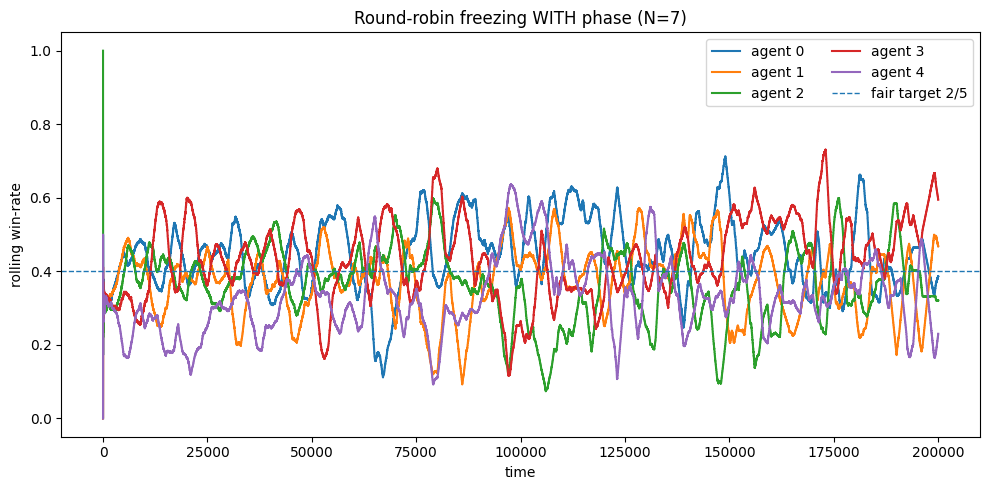

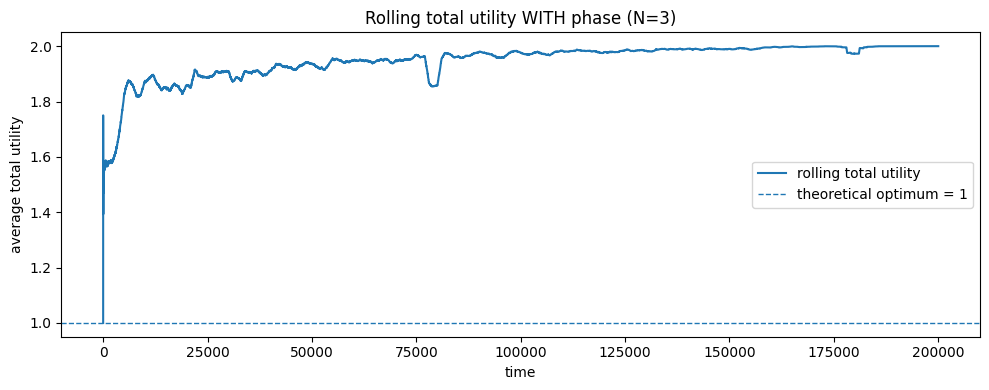

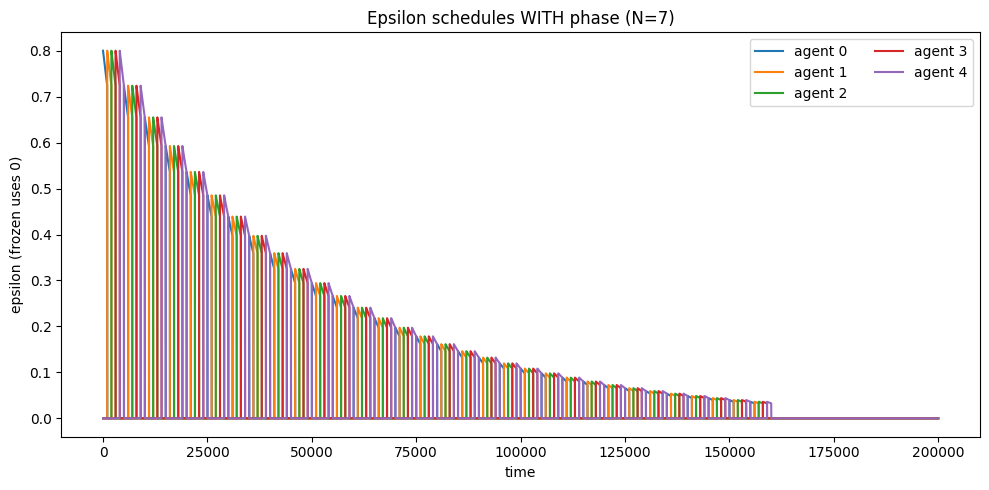

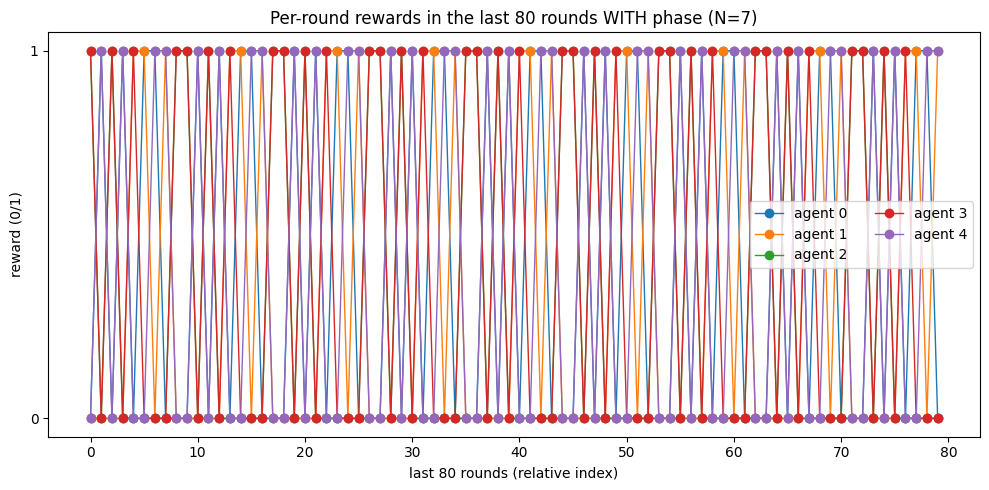


Final avg win-rate (last 5000 steps):
[0.3984 0.4152 0.3254 0.5892 0.2716]

Total avg win-rate:
[0.44709 0.37299 0.36465 0.43517 0.3312 ]

Final avg total utility (last 5000 steps):
1.9998

Overall avg total utility:
1.9511

Theoretical optimum total utility for N=7: 3.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


# ----------------------------
# Minority Game Environment (general odd N)
# ----------------------------
class MinorityGame:
    """
    General odd N, actions in {0,1}.
    Agents on the strict minority side get reward 1, others 0.
    If tie, all get 0.

    Public history signal:
        minority action (0 or 1) if strict minority exists, else 0.
    History length = m bits -> integer state in [0, 2^m - 1].
    """
    def __init__(self, N=7, m=3, seed=0):
        assert N % 2 == 1, "N must be odd in the Minority Game."
        self.n_agents = N
        self.m = m
        self.base_states = 2 ** m
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.t = 0
        self.hist = deque([0] * self.m, maxlen=self.m)
        return self._hist_to_int()

    def _hist_to_int(self):
        s = 0
        for b in self.hist:
            s = (s << 1) | int(b)
        return s

    def step(self, actions):
        actions = np.asarray(actions, dtype=int)
        n1 = int(actions.sum())
        n0 = self.n_agents - n1

        rewards = np.zeros(self.n_agents, dtype=float)
        minority_action = None

        if n1 < n0:
            minority_action = 1
        elif n0 < n1:
            minority_action = 0

        if minority_action is not None:
            winners = (actions == minority_action)
            rewards[winners] = 1.0

        signal = 0 if minority_action is None else int(minority_action)
        self.hist.append(signal)

        self.t += 1
        next_state = self._hist_to_int()
        return next_state, rewards, minority_action


# ----------------------------
# Q-learning Agent
# ----------------------------
class QAgent:
    def __init__(self, n_states, n_actions=2,
                 alpha=0.1, gamma=0.95,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.999,
                 seed=0):
        self.Q = np.zeros((n_states, n_actions), dtype=float)
        self.alpha = float(alpha)
        self.gamma = float(gamma)

        self.eps = float(eps_start)
        self.eps_start = float(eps_start)
        self.eps_end = float(eps_end)
        self.eps_decay = float(eps_decay)

        self.n_actions = int(n_actions)
        self.rng = np.random.default_rng(seed)

    def act(self, s, eps_override=None):
        eps = self.eps if eps_override is None else float(eps_override)

        if self.rng.random() < eps:
            return int(self.rng.integers(self.n_actions))

        q = self.Q[s]
        max_q = np.max(q)
        max_actions = np.flatnonzero(np.isclose(q, max_q))
        return int(self.rng.choice(max_actions))

    def update(self, s, a, r, s_next):
        td_target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s, a] += self.alpha * (td_target - self.Q[s, a])

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


# ----------------------------
# State augmentation with phase
# ----------------------------
def aug_state(history_state, t, base_states, phase_size):
    """
    history_state in [0, base_states-1]
    phase = t % phase_size
    augmented state in [0, base_states * phase_size - 1]
    """
    phase = t % phase_size
    return int(history_state + phase * base_states)


# ----------------------------
# Round-robin freezing training (WITH PHASE)
# ----------------------------
def run_round_robin_with_phase(
    N=7,
    m=3,
    steps=100000,
    seed=0,
    alpha=0.12,
    gamma=0.95,
    eps_start=0.8,
    eps_end=0.001,
    eps_decay=0.9997,
    epoch_len=1000,
    frozen_eps=0.0,
    log_window=2000,
    eps_off=0.8,
    phase_size=None
):
    env = MinorityGame(N=N, m=m, seed=seed)
    base_states = env.base_states

    if phase_size is None:
        phase_size = N

    n_states = base_states * phase_size

    agents = [
        QAgent(
            n_states=n_states,
            n_actions=2,
            alpha=alpha,
            gamma=gamma,
            eps_start=eps_start,
            eps_end=eps_end,
            eps_decay=eps_decay,
            seed=seed + 100 + i
        )
        for i in range(N)
    ]

    history_state = env.reset()

    rewards_hist = np.zeros((steps, N), dtype=float)
    eps_hist = np.zeros((steps, N), dtype=float)
    learner_hist = np.zeros(steps, dtype=int)
    actions_hist = np.zeros((steps, N), dtype=int)
    minority_hist = np.full(steps, -1, dtype=int)
    total_utility_hist = np.zeros(steps, dtype=float)

    eps_off_time = int(eps_off * steps)

    for t in range(steps):
        if t >= eps_off_time:
            for ag in agents:
                ag.eps = 0.0
                ag.eps_end = 0.0

        learner = (t // epoch_len) % N
        learner_hist[t] = learner

        s = aug_state(history_state, t, base_states, phase_size)

        actions = []
        for i, ag in enumerate(agents):
            if i == learner:
                actions.append(ag.act(s))
            else:
                actions.append(ag.act(s, frozen_eps))

        actions = np.asarray(actions, dtype=int)
        next_history_state, rewards, minority_action = env.step(actions)
        s_next = aug_state(next_history_state, t + 1, base_states, phase_size)

        agents[learner].update(s, actions[learner], rewards[learner], s_next)

        if t < eps_off_time:
            agents[learner].decay_eps()

        rewards_hist[t] = rewards
        actions_hist[t] = actions
        minority_hist[t] = -1 if minority_action is None else minority_action
        total_utility_hist[t] = rewards.sum()
        history_state = next_history_state

        for i, ag in enumerate(agents):
            eps_hist[t, i] = ag.eps if i == learner else frozen_eps

    print("eps at end:", [ag.eps for ag in agents])
    print("eps_end:", [ag.eps_end for ag in agents])

    # rolling win-rate
    win_rate = np.zeros((steps, N), dtype=float)
    for i in range(N):
        csum = np.cumsum(rewards_hist[:, i])
        for t in range(steps):
            lo = max(0, t - log_window + 1)
            total = csum[t] - (csum[lo - 1] if lo > 0 else 0.0)
            win_rate[t, i] = total / (t - lo + 1)

    # rolling total utility
    rolling_total_utility = np.zeros(steps, dtype=float)
    csum_u = np.cumsum(total_utility_hist)
    for t in range(steps):
        lo = max(0, t - log_window + 1)
        total = csum_u[t] - (csum_u[lo - 1] if lo > 0 else 0.0)
        rolling_total_utility[t] = total / (t - lo + 1)

    return {
        "rewards_hist": rewards_hist,
        "eps_hist": eps_hist,
        "win_rate": win_rate,
        "learner_hist": learner_hist,
        "actions_hist": actions_hist,
        "minority_hist": minority_hist,
        "total_utility_hist": total_utility_hist,
        "rolling_total_utility": rolling_total_utility,
        "agents": agents,
        "phase_size": phase_size,
        "base_states": base_states
    }


# ----------------------------
# Example run for N=7 with phase
# ----------------------------
if __name__ == "__main__":
    out = run_round_robin_with_phase(
        N=5,
        m=3,
        steps=200000,
        seed=7,
        alpha=0.12,
        gamma=0.95,
        eps_start=0.8,
        eps_end=0.01,
        eps_decay=0.9999,
        epoch_len=1000,
        frozen_eps=0.0,
        log_window=3000,
        eps_off=0.8,
        phase_size=3
    )

    rewards_hist = out["rewards_hist"]
    eps_hist = out["eps_hist"]
    win_rate = out["win_rate"]
    total_utility_hist = out["total_utility_hist"]
    rolling_total_utility = out["rolling_total_utility"]
    agents = out["agents"]

    T = rewards_hist.shape[0]
    t = np.arange(T)

    # ----------------------------
    # Plot 1: rolling win-rate of each agent
    # ----------------------------
    plt.figure(figsize=(10, 5))
    for i in range(rewards_hist.shape[1]):
        plt.plot(t, win_rate[:, i], label=f"agent {i}")
    plt.axhline(2/5, linestyle="--", linewidth=1, label="fair target 2/5")
    plt.xlabel("time")
    plt.ylabel("rolling win-rate")
    plt.title("Round-robin freezing WITH phase (N=7)")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 2: rolling total utility
    # theoretical max = (N-1)/2 = 3
    # ----------------------------
    plt.figure(figsize=(10, 4))
    plt.plot(t, rolling_total_utility, label="rolling total utility")
    plt.axhline((3 - 1) / 2, linestyle="--", linewidth=1, label="theoretical optimum = 1")
    plt.xlabel("time")
    plt.ylabel("average total utility")
    plt.title("Rolling total utility WITH phase (N=3)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 3: epsilon schedules
    # ----------------------------
    plt.figure(figsize=(10, 5))
    for i in range(rewards_hist.shape[1]):
        plt.plot(t, eps_hist[:, i], label=f"agent {i}")
    plt.xlabel("time")
    plt.ylabel("epsilon (frozen uses 0)")
    plt.title("Epsilon schedules WITH phase (N=7)")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 4: last 80 rounds rewards
    # ----------------------------
    last = 80
    R = rewards_hist[-last:]
    x = np.arange(last)

    plt.figure(figsize=(10, 5))
    for i in range(rewards_hist.shape[1]):
        plt.plot(x, R[:, i], marker='o', linewidth=1, label=f'agent {i}')
    plt.yticks([0, 1])
    plt.xlabel(f'last {last} rounds (relative index)')
    plt.ylabel('reward (0/1)')
    plt.title(f'Per-round rewards in the last {last} rounds WITH phase (N=7)')
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Print summary
    # ----------------------------
    print("\nFinal avg win-rate (last 5000 steps):")
    print(rewards_hist[-5000:].mean(axis=0))

    print("\nTotal avg win-rate:")
    print(rewards_hist.mean(axis=0))

    print("\nFinal avg total utility (last 5000 steps):")
    print(total_utility_hist[-5000:].mean())

    print("\nOverall avg total utility:")
    print(total_utility_hist.mean())

    print("\nTheoretical optimum total utility for N=7:", (7 - 1) / 2)



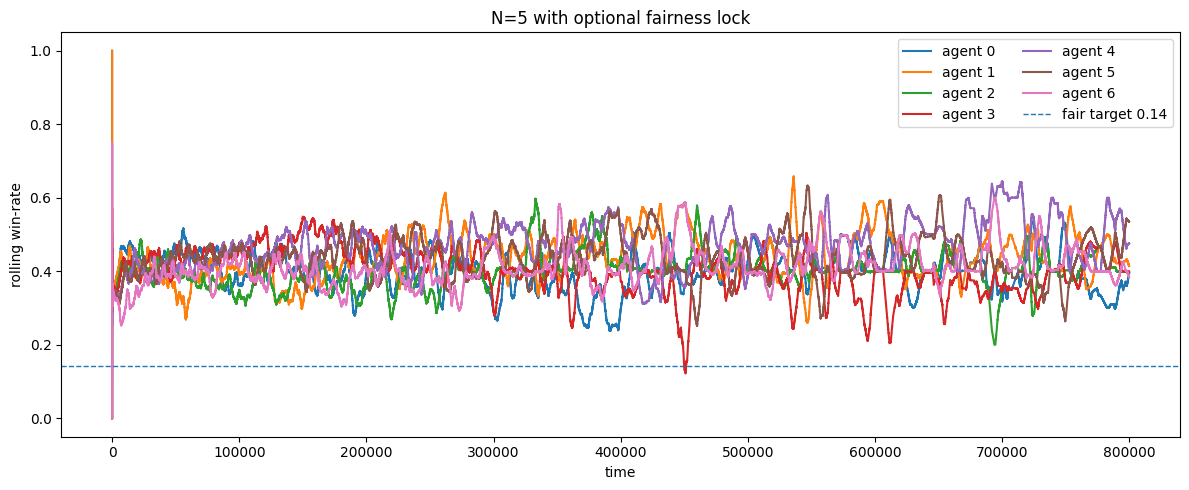

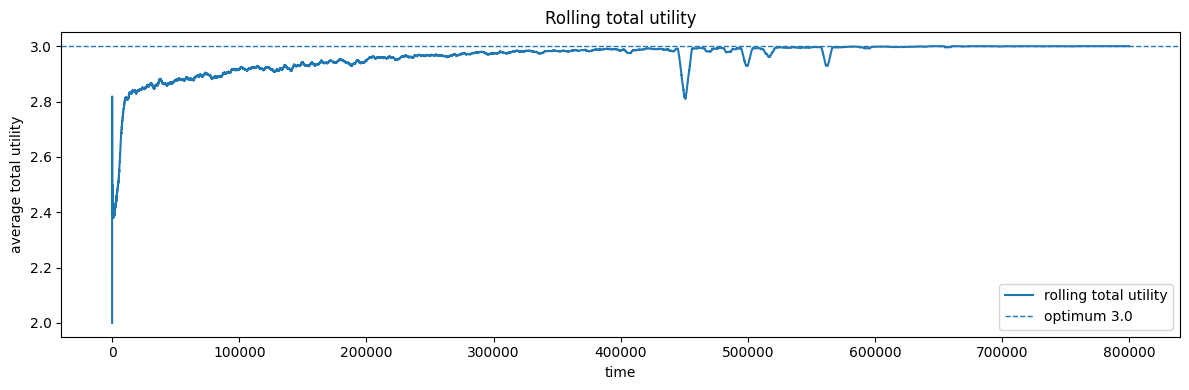

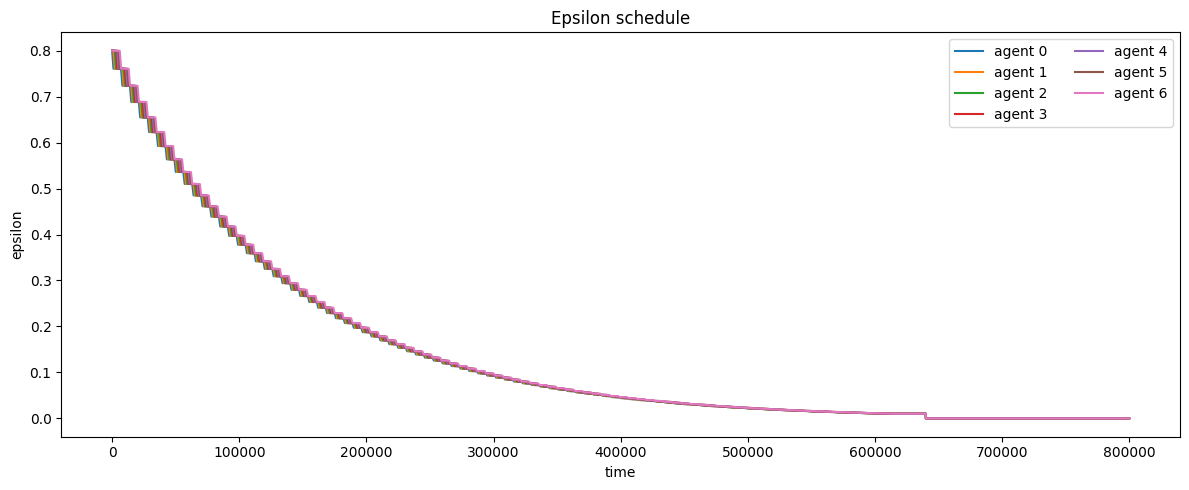

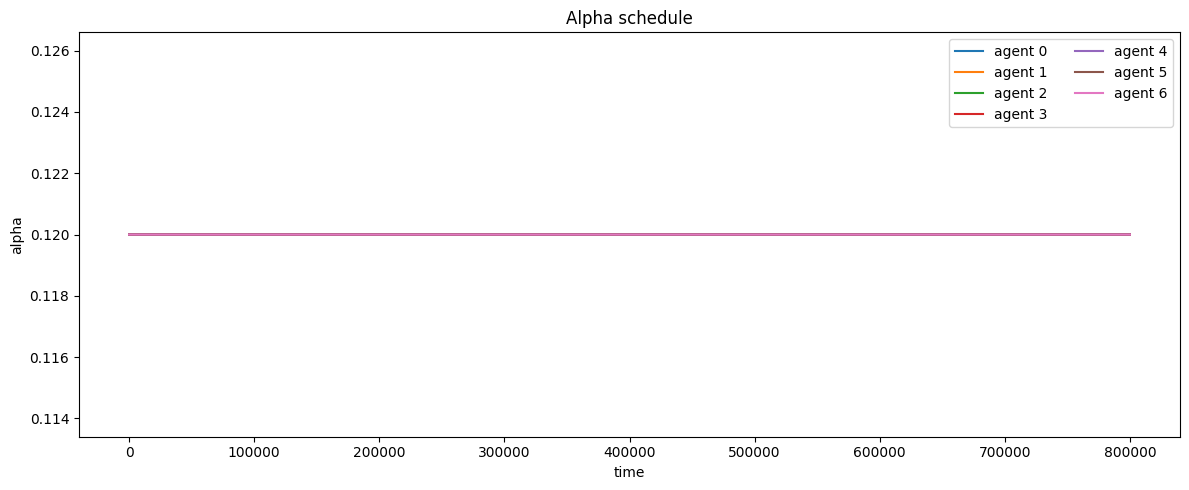

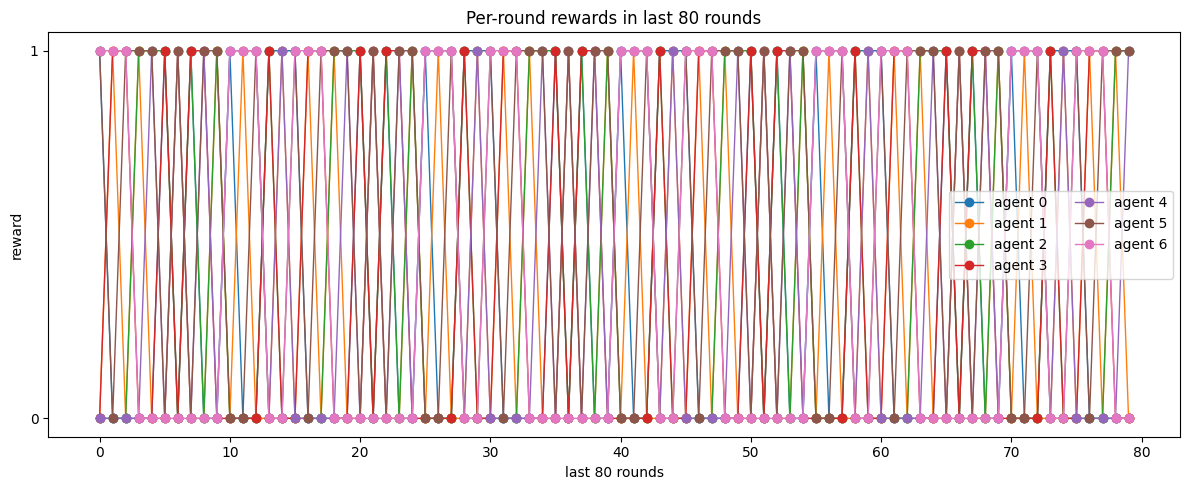


Final avg win-rate (last 5000 steps):
[0.3952 0.4142 0.397  0.3996 0.4758 0.5344 0.3838]

Overall avg win-rate:
[0.39975625 0.43784125 0.40231625 0.401315   0.47112875 0.43775
 0.41228625]

Final avg total utility (last 5000 steps):
3.0

Overall avg total utility:
2.96239375

Theoretical optimum total utility: 3.0

Fairness lock trigger time: None

Final agent alphas:
[0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12]

Final agent epsilons:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


# ----------------------------
# Minority Game Environment
# ----------------------------
class MinorityGame:
    """
    General odd N, actions in {0,1}.
    Agents on the strict minority side get reward 1, others 0.
    If tie, all get 0.

    Public history signal:
        minority action (0 or 1) if strict minority exists, else 0.
    """
    def __init__(self, N=5, m=3, seed=0):
        assert N % 2 == 1, "N must be odd."
        self.n_agents = N
        self.m = m
        self.base_states = 2 ** m
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.t = 0
        self.hist = deque([0] * self.m, maxlen=self.m)
        return self._hist_to_int()

    def _hist_to_int(self):
        s = 0
        for b in self.hist:
            s = (s << 1) | int(b)
        return s

    def step(self, actions):
        actions = np.asarray(actions, dtype=int)
        n1 = int(actions.sum())
        n0 = self.n_agents - n1

        rewards = np.zeros(self.n_agents, dtype=float)
        minority_action = None

        if n1 < n0:
            minority_action = 1
        elif n0 < n1:
            minority_action = 0

        if minority_action is not None:
            rewards[actions == minority_action] = 1.0

        signal = 0 if minority_action is None else int(minority_action)
        self.hist.append(signal)
        self.t += 1

        next_state = self._hist_to_int()
        return next_state, rewards, minority_action


# ----------------------------
# Q-learning Agent
# ----------------------------
class QAgent:
    def __init__(self, n_states, n_actions=2,
                 alpha=0.12, gamma=0.95,
                 eps_start=0.8, eps_end=0.001, eps_decay=0.9997,
                 seed=0):
        self.Q = np.zeros((n_states, n_actions), dtype=float)

        self.alpha = float(alpha)
        self.alpha_init = float(alpha)

        self.gamma = float(gamma)

        self.eps = float(eps_start)
        self.eps_start = float(eps_start)
        self.eps_end = float(eps_end)
        self.eps_decay = float(eps_decay)

        self.n_actions = int(n_actions)
        self.rng = np.random.default_rng(seed)

    def act(self, s, eps_override=None):
        eps = self.eps if eps_override is None else float(eps_override)

        if self.rng.random() < eps:
            return int(self.rng.integers(self.n_actions))

        q = self.Q[s]
        max_q = np.max(q)
        max_actions = np.flatnonzero(np.isclose(q, max_q))
        return int(self.rng.choice(max_actions))

    def update(self, s, a, r, s_next):
        if self.alpha <= 0.0:
            return
        td_target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s, a] += self.alpha * (td_target - self.Q[s, a])

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


# ----------------------------
# augmented state: history + phase
# ----------------------------
def aug_state(history_state, t, base_states, phase_size):
    phase = t % phase_size
    return int(history_state + phase * base_states)


# ----------------------------
# rolling mean helper
# ----------------------------
def rolling_mean_1d(x, window):
    out = np.zeros_like(x, dtype=float)
    csum = np.cumsum(x, dtype=float)
    for t in range(len(x)):
        lo = max(0, t - window + 1)
        total = csum[t] - (csum[lo - 1] if lo > 0 else 0.0)
        out[t] = total / (t - lo + 1)
    return out


# ----------------------------
# fairness detection
# ----------------------------
def fairness_detected(rewards_hist, total_utility_hist, t,
                      N,
                      fairness_window=5000,
                      reward_tol=0.02,
                      utility_tol=0.02):
    """
    Check whether the system is near fair periodicity over the recent window.

    Conditions:
    1. each agent's average reward is close to 1/N
    2. average total utility is close to (N-1)/2
    """
    if t + 1 < fairness_window:
        return False

    lo = t + 1 - fairness_window
    recent_rewards = rewards_hist[lo:t+1]
    recent_utility = total_utility_hist[lo:t+1]

    avg_rewards = recent_rewards.mean(axis=0)
    avg_total_utility = recent_utility.mean()

    fair_target = 1.0 / N
    utility_target = (N - 1) / 2.0

    rewards_ok = np.all(np.abs(avg_rewards - fair_target) <= reward_tol)
    utility_ok = abs(avg_total_utility - utility_target) <= utility_tol

    return rewards_ok and utility_ok


# ----------------------------
# Round-robin freezing with phase + optional fairness lock
# ----------------------------
def run_round_robin_with_phase_fairness_lock(
    N=7,
    m=5,
    steps=800000,
    seed=42,
    alpha=0.12,
    gamma=0.95,
    eps_start=0.8,
    eps_end=0.001,
    eps_decay=0.9997,
    epoch_len=3000,
    frozen_eps=0.0,
    log_window=5000,
    eps_off=0.8,
    phase_size=None,
    # ---- fairness lock parameters ----
    enable_fairness_lock=True,
    fairness_window=5000,
    reward_tol=0.02,
    utility_tol=0.02
):
    assert N % 2 == 1

    env = MinorityGame(N=N, m=m, seed=seed)
    base_states = env.base_states

    if phase_size is None:
        phase_size = N

    n_states = base_states * phase_size

    agents = [
        QAgent(
            n_states=n_states,
            n_actions=2,
            alpha=alpha,
            gamma=gamma,
            eps_start=eps_start,
            eps_end=eps_end,
            eps_decay=eps_decay,
            seed=seed + 100 + i
        )
        for i in range(N)
    ]

    history_state = env.reset()

    rewards_hist = np.zeros((steps, N), dtype=float)
    actions_hist = np.zeros((steps, N), dtype=int)
    learner_hist = np.zeros(steps, dtype=int)
    eps_hist = np.zeros((steps, N), dtype=float)
    alpha_hist = np.zeros((steps, N), dtype=float)
    minority_hist = np.full(steps, -1, dtype=int)
    total_utility_hist = np.zeros(steps, dtype=float)

    fairness_lock_hist = np.zeros(steps, dtype=int)
    fairness_lock_trigger_time = None
    fairness_locked = False

    eps_off_time = int(eps_off * steps)

    for t in range(steps):
        # If fairness lock is already triggered, force full greedy + no learning
        if fairness_locked:
            for ag in agents:
                ag.eps = 0.0
                ag.eps_end = 0.0
                ag.alpha = 0.0
        else:
            # Original eps_off mechanism
            if t >= eps_off_time:
                for ag in agents:
                    ag.eps = 0.0
                    ag.eps_end = 0.0

        learner = (t // epoch_len) % N
        learner_hist[t] = learner

        s = aug_state(history_state, t, base_states, phase_size)

        actions = []
        for i, ag in enumerate(agents):
            if fairness_locked:
                # once locked, everyone acts greedily
                a = ag.act(s, eps_override=0.0)
            else:
                if i == learner:
                    a = ag.act(s)
                else:
                    a = ag.act(s, eps_override=frozen_eps)
            actions.append(a)

        actions = np.asarray(actions, dtype=int)

        next_history_state, rewards, minority_action = env.step(actions)
        s_next = aug_state(next_history_state, t + 1, base_states, phase_size)

        # only learner updates before fairness lock
        if not fairness_locked:
            agents[learner].update(s, actions[learner], rewards[learner], s_next)

            if t < eps_off_time:
                agents[learner].decay_eps()

        rewards_hist[t] = rewards
        actions_hist[t] = actions
        minority_hist[t] = -1 if minority_action is None else minority_action
        total_utility_hist[t] = rewards.sum()
        history_state = next_history_state

        for i, ag in enumerate(agents):
            eps_hist[t, i] = ag.eps if (not fairness_locked and i == learner) else ag.eps
            alpha_hist[t, i] = ag.alpha

        # ---- fairness detection after recording current step ----
        if enable_fairness_lock and (not fairness_locked):
            if fairness_detected(
                rewards_hist=rewards_hist,
                total_utility_hist=total_utility_hist,
                t=t,
                N=N,
                fairness_window=fairness_window,
                reward_tol=reward_tol,
                utility_tol=utility_tol
            ):
                fairness_locked = True
                fairness_lock_trigger_time = t
                fairness_lock_hist[t:] = 1

                for ag in agents:
                    ag.eps = 0.0
                    ag.eps_end = 0.0
                    ag.alpha = 0.0

                print(f"Fairness lock triggered at t = {t}")

    # rolling win-rate
    win_rate = np.zeros((steps, N), dtype=float)
    for i in range(N):
        win_rate[:, i] = rolling_mean_1d(rewards_hist[:, i], log_window)

    rolling_total_utility = rolling_mean_1d(total_utility_hist, log_window)

    return {
        "rewards_hist": rewards_hist,
        "actions_hist": actions_hist,
        "learner_hist": learner_hist,
        "eps_hist": eps_hist,
        "alpha_hist": alpha_hist,
        "minority_hist": minority_hist,
        "total_utility_hist": total_utility_hist,
        "win_rate": win_rate,
        "rolling_total_utility": rolling_total_utility,
        "agents": agents,
        "phase_size": phase_size,
        "base_states": base_states,
        "fairness_lock_hist": fairness_lock_hist,
        "fairness_lock_trigger_time": fairness_lock_trigger_time
    }


# ----------------------------
# Run experiment: N = 5
# ----------------------------
if __name__ == "__main__":
    out = run_round_robin_with_phase_fairness_lock(
        N=7,
        m=5,
        steps=800000,
        seed=42,
        alpha=0.12,
        gamma=0.95,
        eps_start=0.8,
        eps_end=0.01,
        eps_decay=0.99995,
        epoch_len=1000,
        frozen_eps=0.0,
        log_window=5000,
        eps_off=0.8,
        phase_size=5,
        enable_fairness_lock=False,
        fairness_window=2000,
        reward_tol=0.02,
        utility_tol=0.02
    )

    rewards_hist = out["rewards_hist"]
    actions_hist = out["actions_hist"]
    learner_hist = out["learner_hist"]
    eps_hist = out["eps_hist"]
    alpha_hist = out["alpha_hist"]
    total_utility_hist = out["total_utility_hist"]
    win_rate = out["win_rate"]
    rolling_total_utility = out["rolling_total_utility"]
    fairness_lock_hist = out["fairness_lock_hist"]
    fairness_lock_trigger_time = out["fairness_lock_trigger_time"]
    agents = out["agents"]

    T, N = rewards_hist.shape
    t = np.arange(T)

    # ----------------------------
    # Plot 1: rolling win-rate
    # ----------------------------
    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(t, win_rate[:, i], label=f"agent {i}")
    plt.axhline(1 / N, linestyle="--", linewidth=1, label=f"fair target {1/N:.2f}")
    plt.xlabel("time")
    plt.ylabel("rolling win-rate")
    plt.title("N=5 with optional fairness lock")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 2: rolling total utility
    # ----------------------------
    plt.figure(figsize=(12, 4))
    plt.plot(t, rolling_total_utility, label="rolling total utility")
    plt.axhline((N - 1) / 2, linestyle="--", linewidth=1, label=f"optimum {(N - 1)/2:.1f}")
    if fairness_lock_trigger_time is not None:
        plt.axvline(fairness_lock_trigger_time, linestyle=":", linewidth=2, label="fairness lock")
    plt.xlabel("time")
    plt.ylabel("average total utility")
    plt.title("Rolling total utility")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 3: epsilon schedule
    # ----------------------------
    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(t, eps_hist[:, i], label=f"agent {i}")
    if fairness_lock_trigger_time is not None:
        plt.axvline(fairness_lock_trigger_time, linestyle=":", linewidth=2, label="fairness lock")
    plt.xlabel("time")
    plt.ylabel("epsilon")
    plt.title("Epsilon schedule")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 4: alpha schedule
    # ----------------------------
    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(t, alpha_hist[:, i], label=f"agent {i}")
    plt.xlabel("time")
    plt.ylabel("alpha")
    plt.title("Alpha schedule")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 5: last 80 rewards
    # ----------------------------
    last = 80
    R = rewards_hist[-last:]
    x = np.arange(last)

    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(x, R[:, i], marker='o', linewidth=1, label=f'agent {i}')
    plt.yticks([0, 1])
    plt.xlabel(f'last {last} rounds')
    plt.ylabel('reward')
    plt.title(f'Per-round rewards in last {last} rounds')
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Print summary
    # ----------------------------
    print("\nFinal avg win-rate (last 5000 steps):")
    print(rewards_hist[-5000:].mean(axis=0))

    print("\nOverall avg win-rate:")
    print(rewards_hist.mean(axis=0))

    print("\nFinal avg total utility (last 5000 steps):")
    print(total_utility_hist[-5000:].mean())

    print("\nOverall avg total utility:")
    print(total_utility_hist.mean())

    print("\nTheoretical optimum total utility:", (N - 1) / 2)

    print("\nFairness lock trigger time:", fairness_lock_trigger_time)

    print("\nFinal agent alphas:")
    print([ag.alpha for ag in agents])

    print("\nFinal agent epsilons:")
    print([ag.eps for ag in agents])

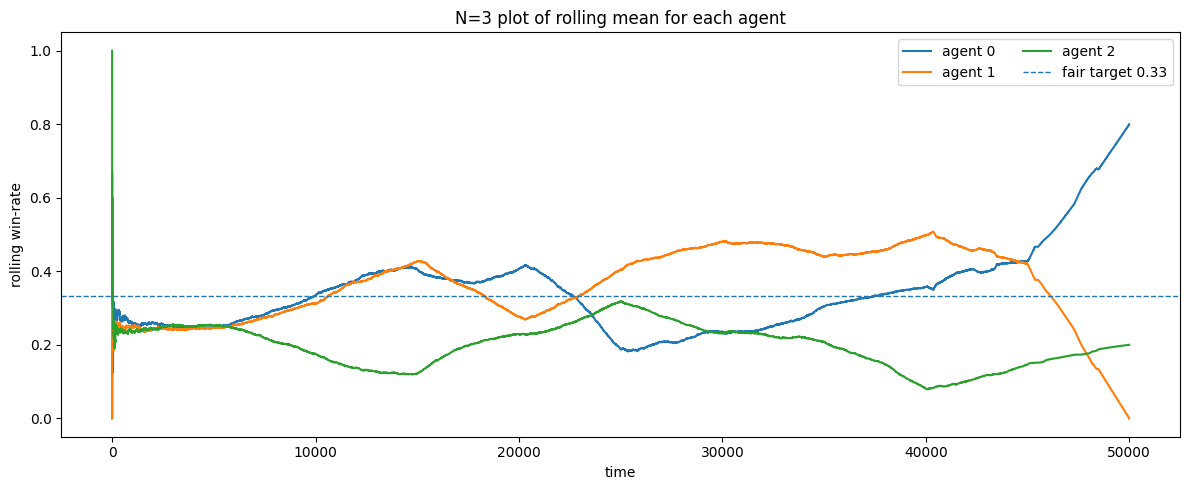

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(N):
    plt.plot(t, win_rate[:, i], label=f"agent {i}")
plt.axhline(1 / N, linestyle="--", linewidth=1, label=f"fair target {1/N:.2f}")
plt.xlabel("time")
plt.ylabel("rolling win-rate")
plt.title("N=3 plot of rolling mean for each agent")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

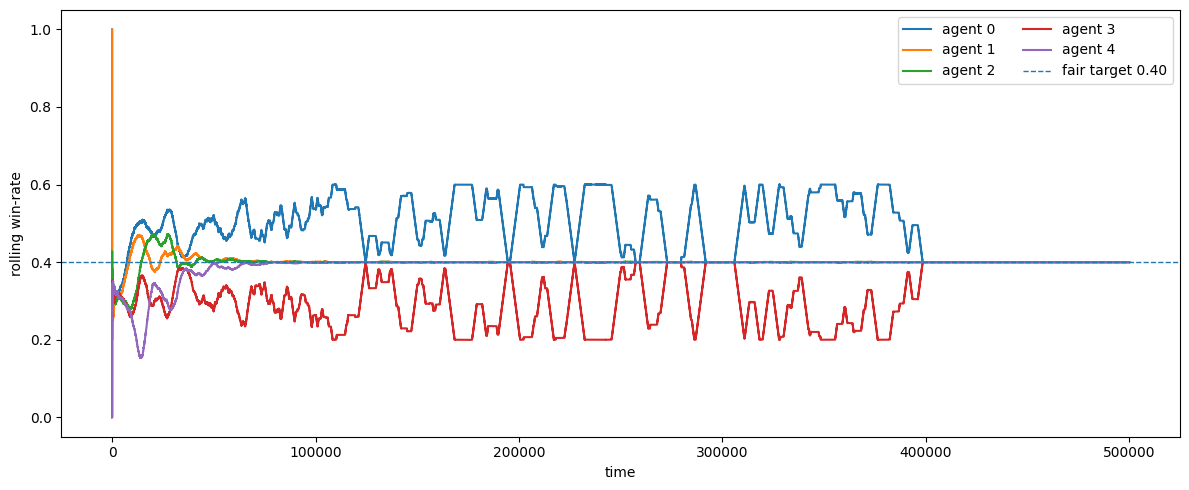

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(N):
      plt.plot(t, win_rate[:, i], label=f"agent {i}")
plt.axhline(2 / N, linestyle="--", linewidth=1, label=f"fair target {2/N:.2f}")
plt.xlabel("time")
plt.ylabel("rolling win-rate")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

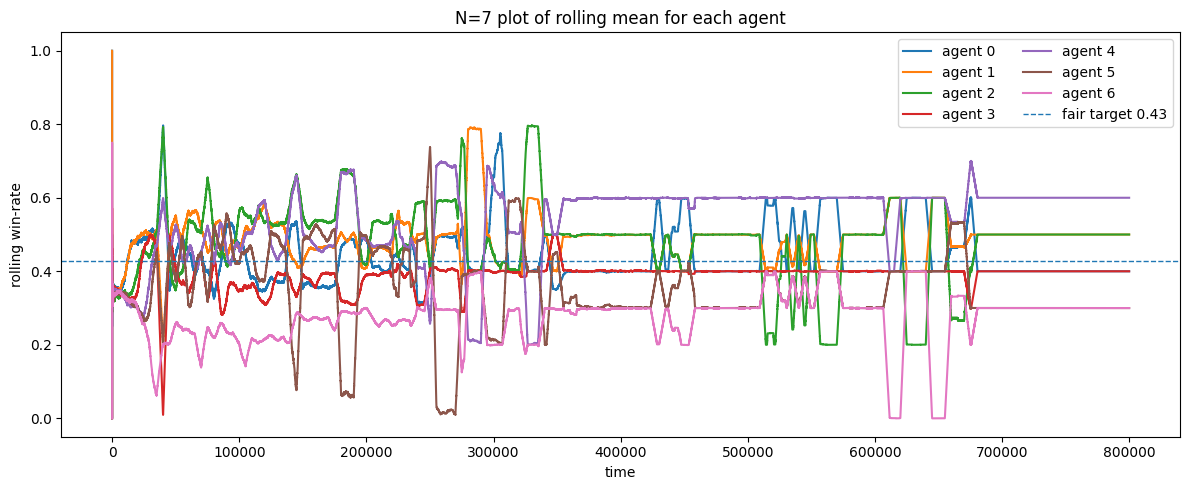

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(N):
  plt.plot(t, win_rate[:, i], label=f"agent {i}")
plt.axhline(3 / N, linestyle="--", linewidth=1, label=f"fair target {3/N:.2f}")
plt.xlabel("time")
plt.ylabel("rolling win-rate")
plt.title("N=7 plot of rolling mean for each agent")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()